# 📊 Sprint 1 — Data Understanding & EDA

**Objective:** Inspect the raw hotel bookings dataset, understand distributions, identify data quality issues, and discover relationships with the cancellation target.

---

In [1]:
# ── Imports ──
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_raw_data
from src.utils.config import FIGURES_DIR, RAW_DATA_FILE

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load & Inspect

In [2]:
df = load_raw_data()
print(f'Shape: {df.shape}')
df.head()

2026-08-25 00:48:44 │ INFO     │ src.data.load_data │ Loading raw data from C:\Users\pares\OneDrive\Desktop\hotle_cnacelation\hotel_bookings.csv
2026-08-25 00:48:45 │ INFO     │ src.data.load_data │ Shape: (119390, 32)
2026-08-25 00:48:45 │ INFO     │ src.data.load_data │ Columns: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']
2026-08-25 00:48:45 │ WARNING  │ src.data.load_data │ Columns with nulls:
children         4
countr

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


## 2. Null / Missing Value Analysis

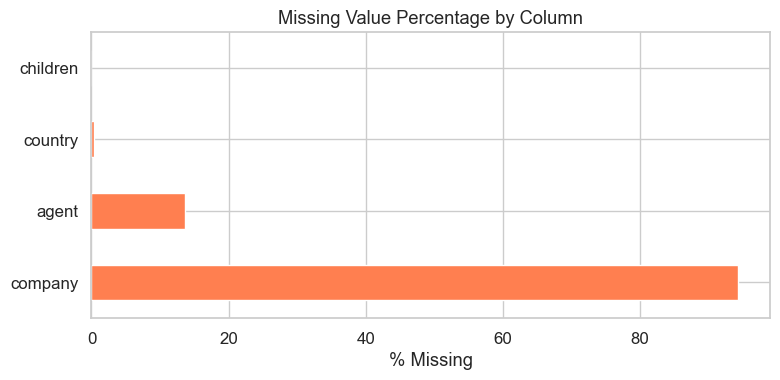

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64


In [5]:
# Replace 'NULL' strings with NaN for accurate counting
df_check = df.replace('NULL', np.nan)

null_pct = (df_check.isnull().sum() / len(df_check) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(8, 4))
null_pct.plot.barh(color='coral', ax=ax)
ax.set_title('Missing Value Percentage by Column')
ax.set_xlabel('% Missing')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'missing_values.png', dpi=150)
plt.show()
print(null_pct)

## 3. Target Distribution

C:\Users\pares\AppData\Local\Temp\ipykernel_40476\1740990801.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Canceled', 'Canceled'])


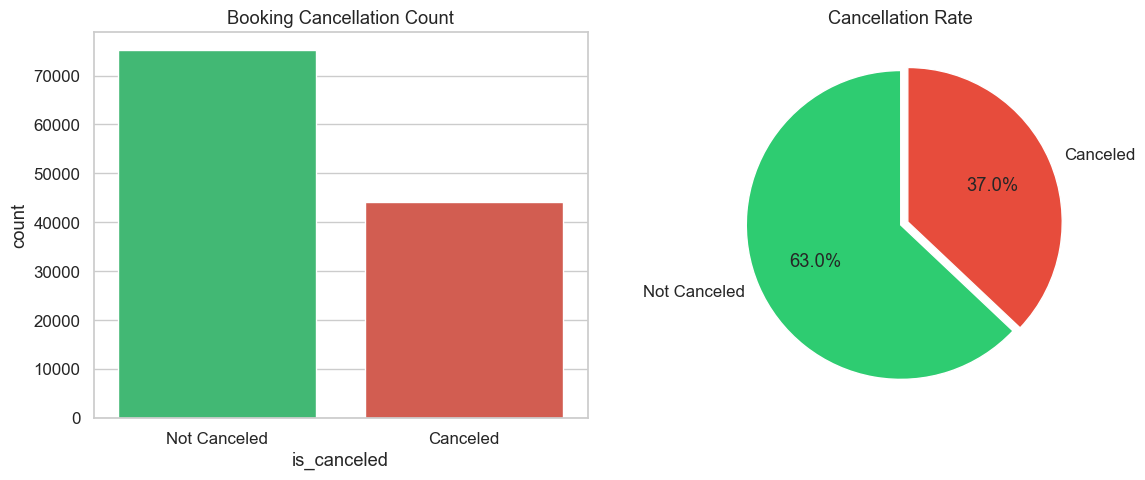

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
sns.countplot(x='is_canceled', data=df, ax=axes[0], hue='is_canceled',
              palette=['#2ecc71', '#e74c3c'], legend=False)
axes[0].set_title('Booking Cancellation Count')
axes[0].set_xticklabels(['Not Canceled', 'Canceled'])

# Pie chart
df['is_canceled'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
    labels=['Not Canceled', 'Canceled'], ax=axes[1],
    startangle=90, explode=(0, 0.05)
)
axes[1].set_ylabel('')
axes[1].set_title('Cancellation Rate')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150)
plt.show()

## 4. Univariate Analysis — Numerical Features

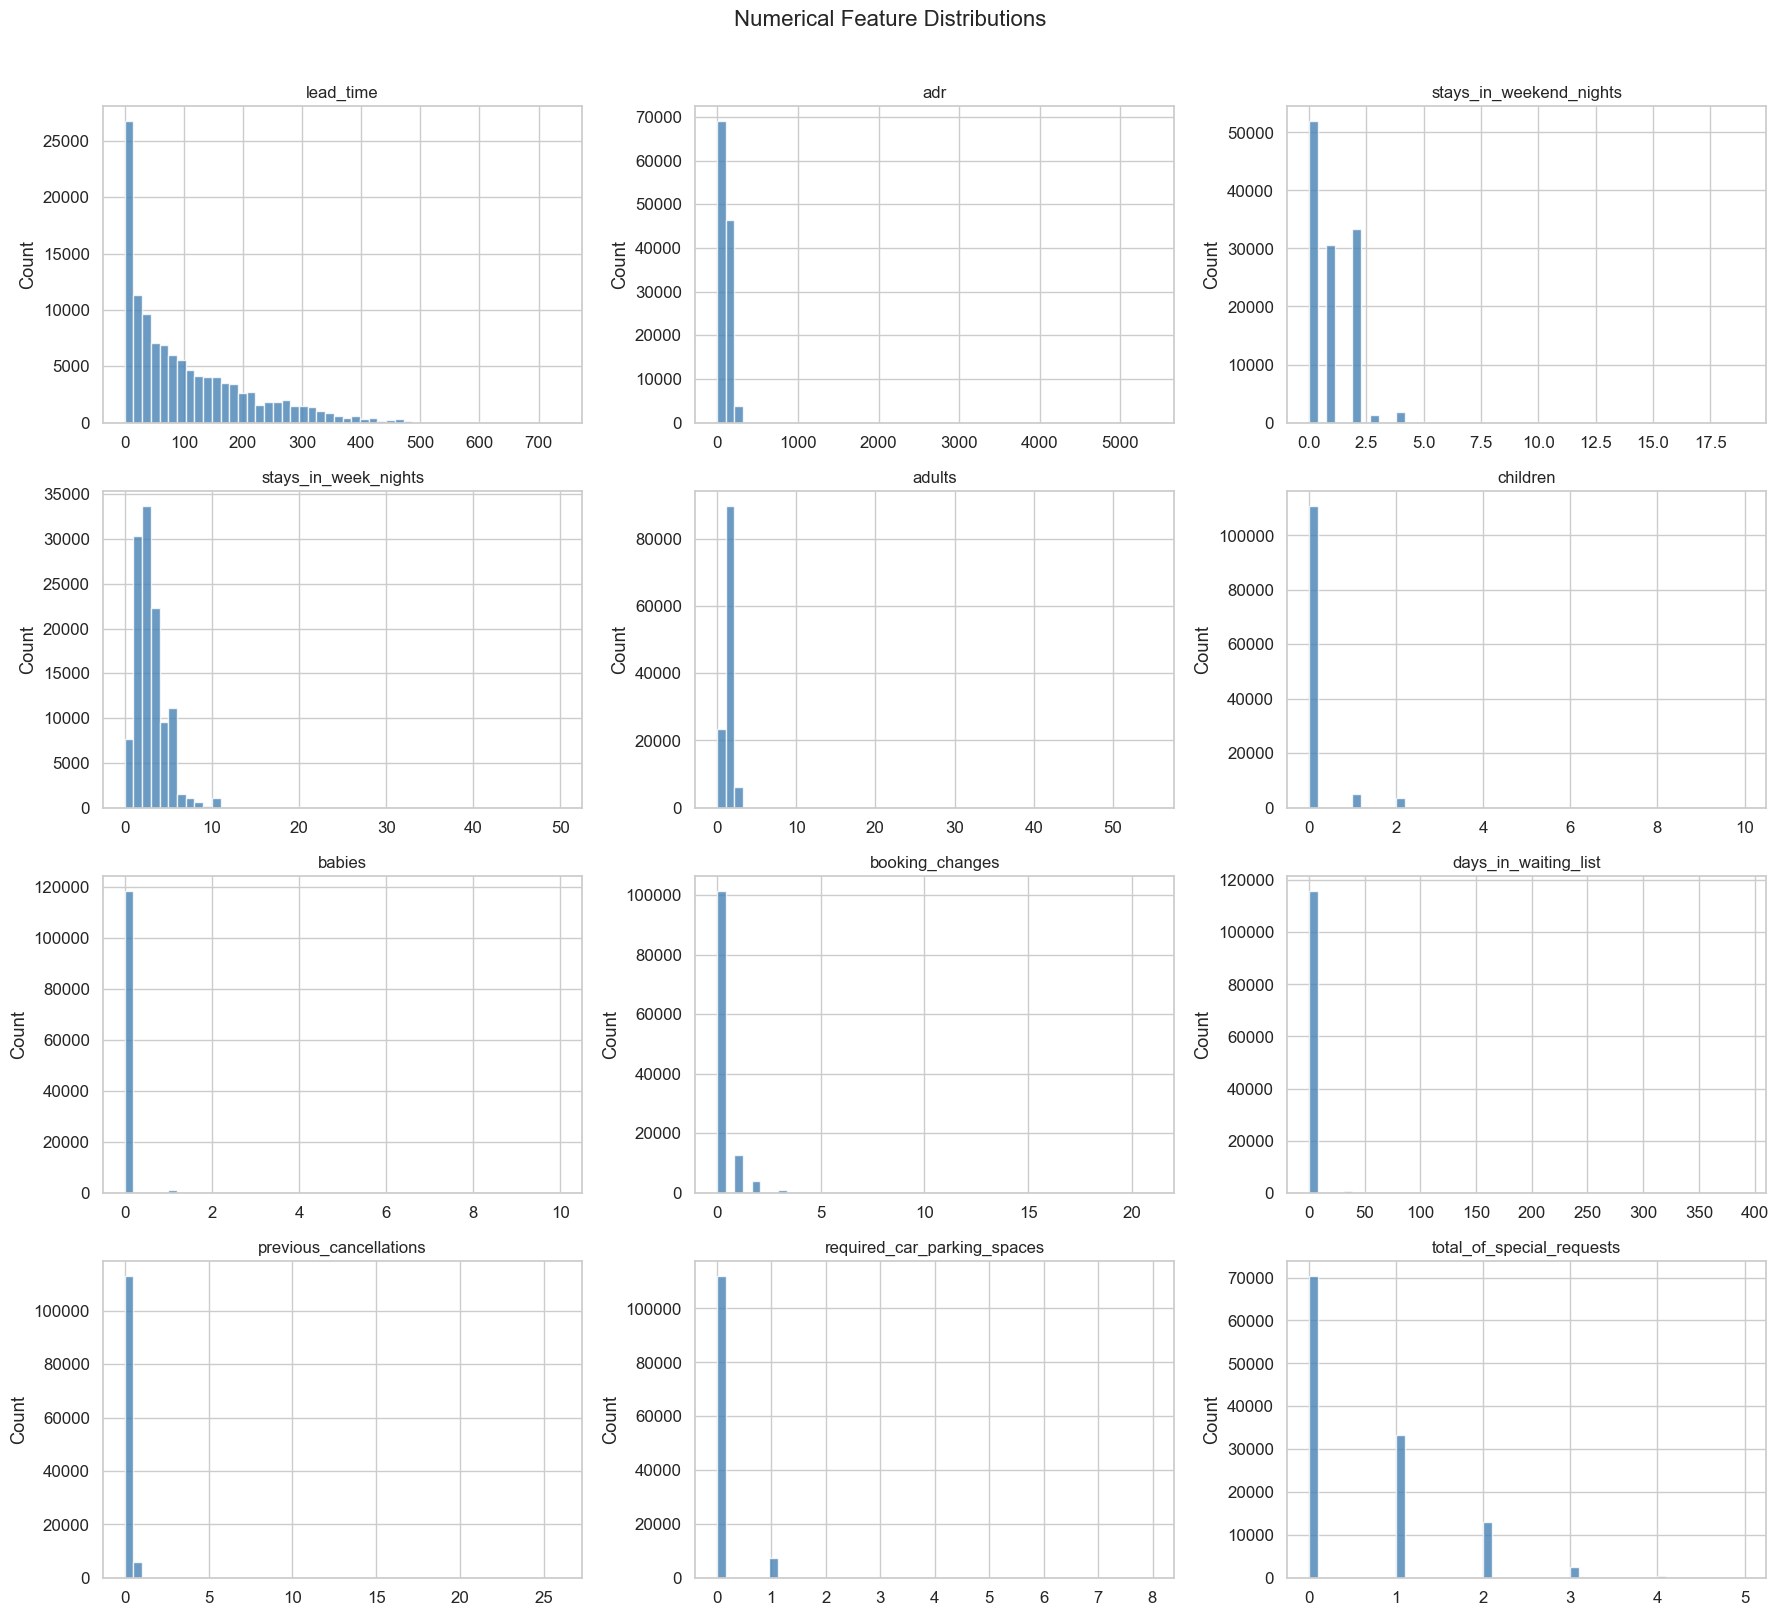

In [7]:
numeric_cols = ['lead_time', 'adr', 'stays_in_weekend_nights', 'stays_in_week_nights',
                'adults', 'children', 'babies', 'booking_changes',
                'days_in_waiting_list', 'previous_cancellations',
                'required_car_parking_spaces', 'total_of_special_requests']

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Feature Distributions', y=1.01, fontsize=16)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'numeric_distributions.png', dpi=150)
plt.show()

## 5. Univariate Analysis — Categorical Features

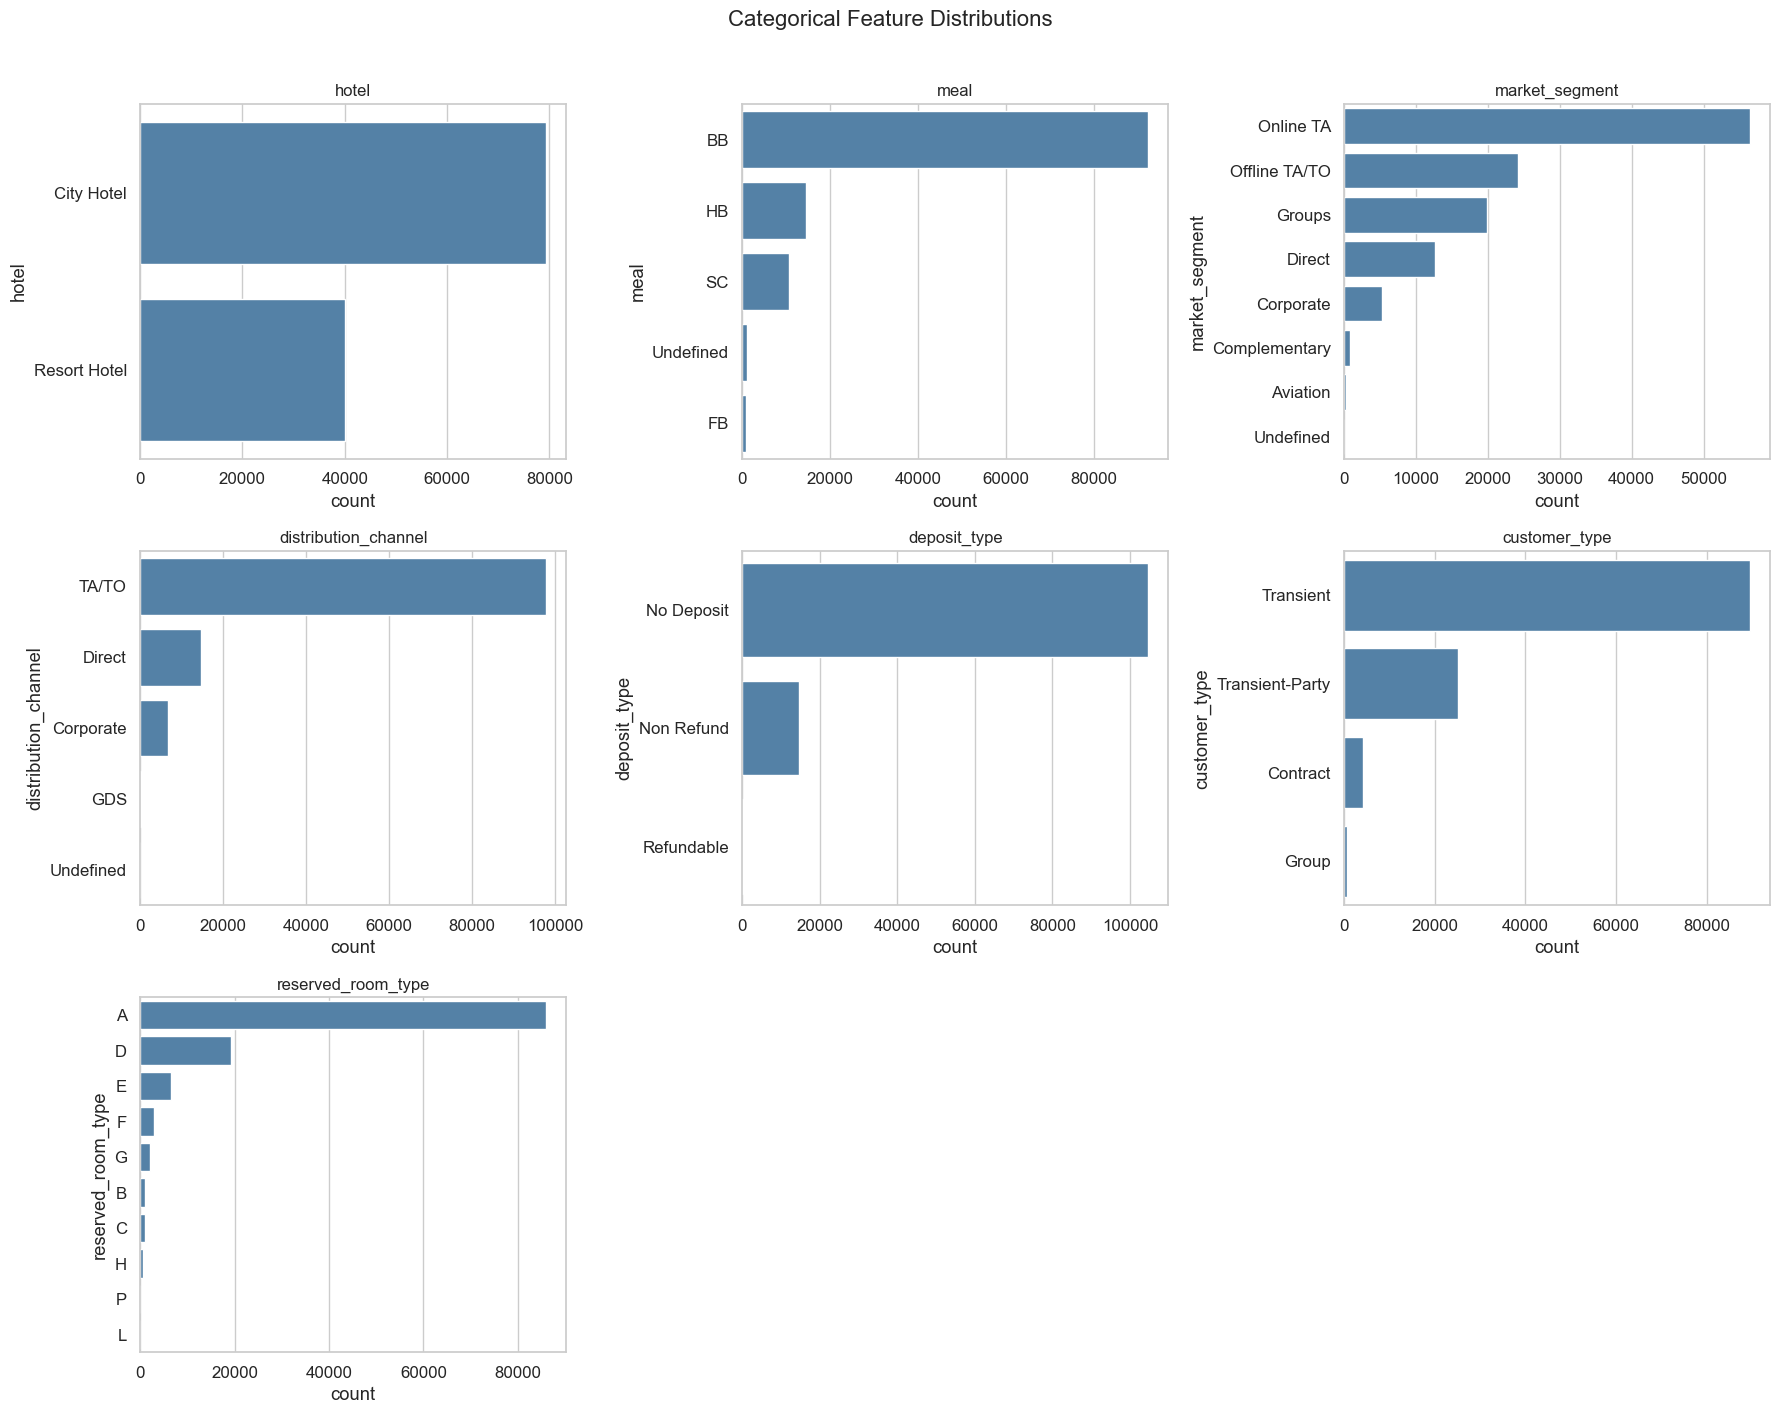

In [8]:
cat_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel',
            'deposit_type', 'customer_type', 'reserved_room_type']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=12)

# Hide unused axes
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', y=1.01, fontsize=16)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'categorical_distributions.png', dpi=150)
plt.show()

## 6. Bivariate Analysis — Cancellation Rate Breakdowns

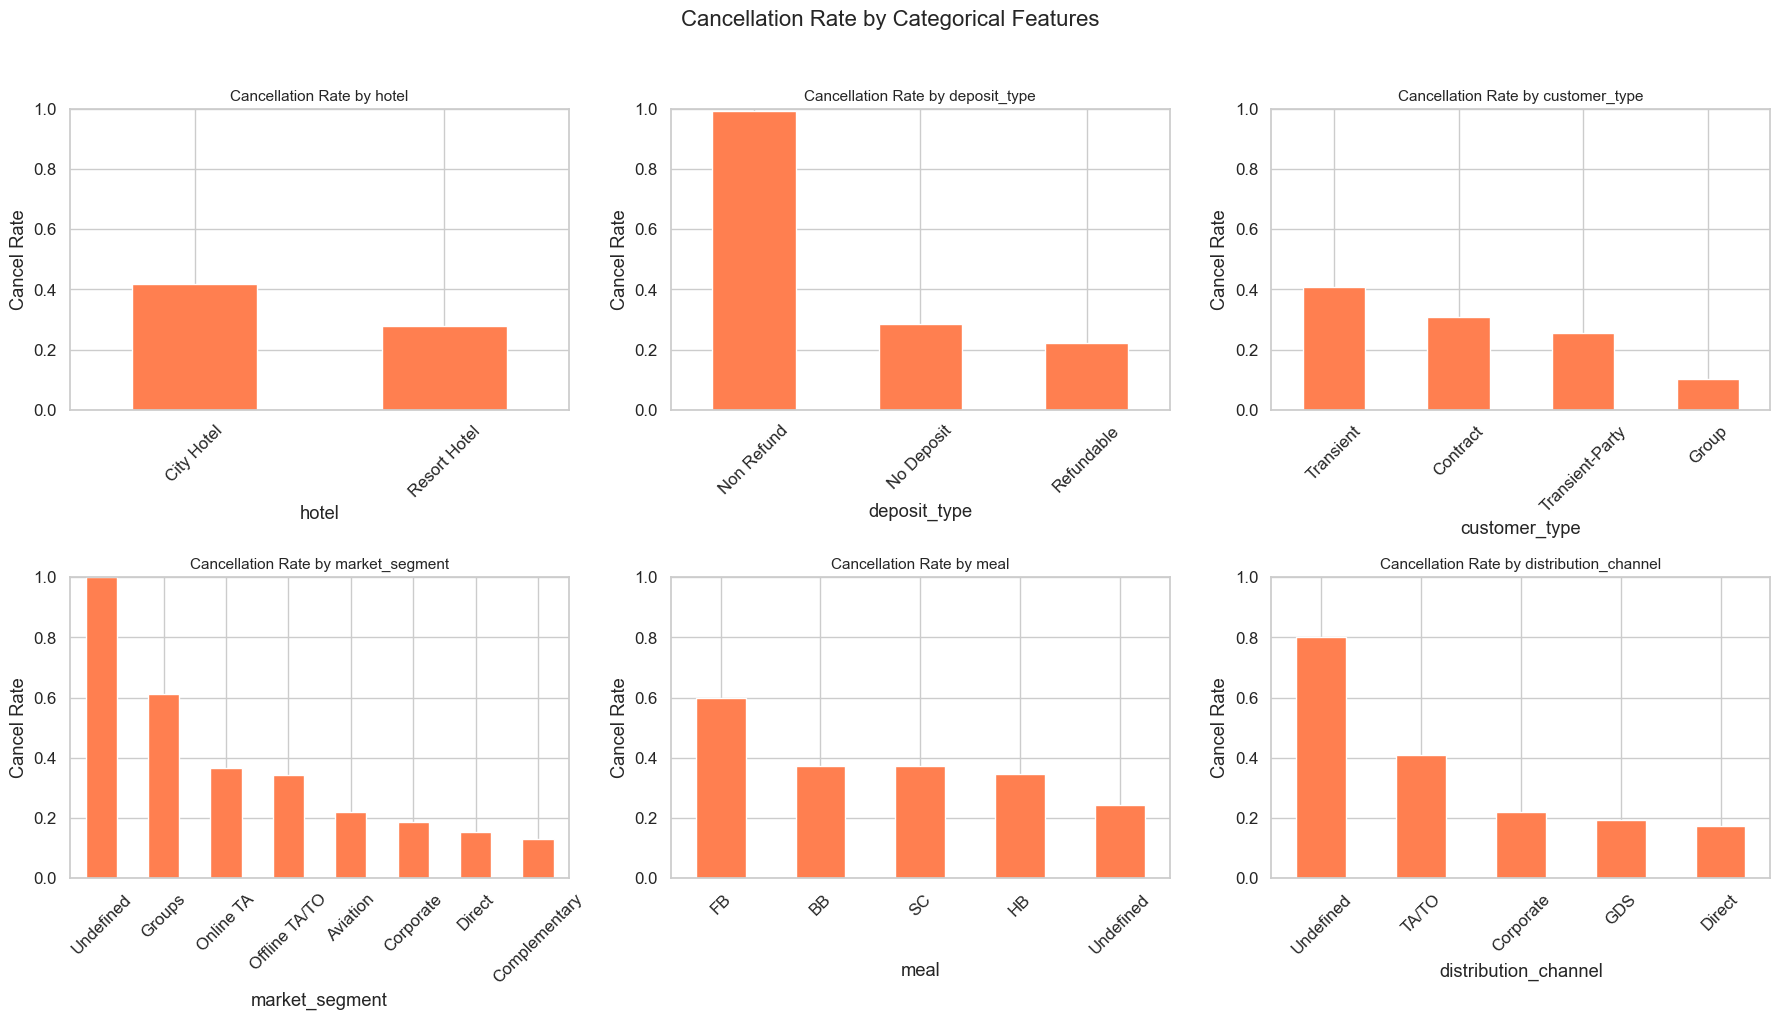

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

bivar_cols = ['hotel', 'deposit_type', 'customer_type',
              'market_segment', 'meal', 'distribution_channel']

for i, col in enumerate(bivar_cols):
    ax = axes.ravel()[i]
    cancel_rate = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    cancel_rate.plot.bar(ax=ax, color='coral', edgecolor='white')
    ax.set_title(f'Cancellation Rate by {col}', fontsize=11)
    ax.set_ylabel('Cancel Rate')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Cancellation Rate by Categorical Features', y=1.02, fontsize=16)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cancellation_by_category.png', dpi=150)
plt.show()

C:\Users\pares\AppData\Local\Temp\ipykernel_40476\1235777865.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['lead_time'], bins=20))['is_canceled'].mean().plot(


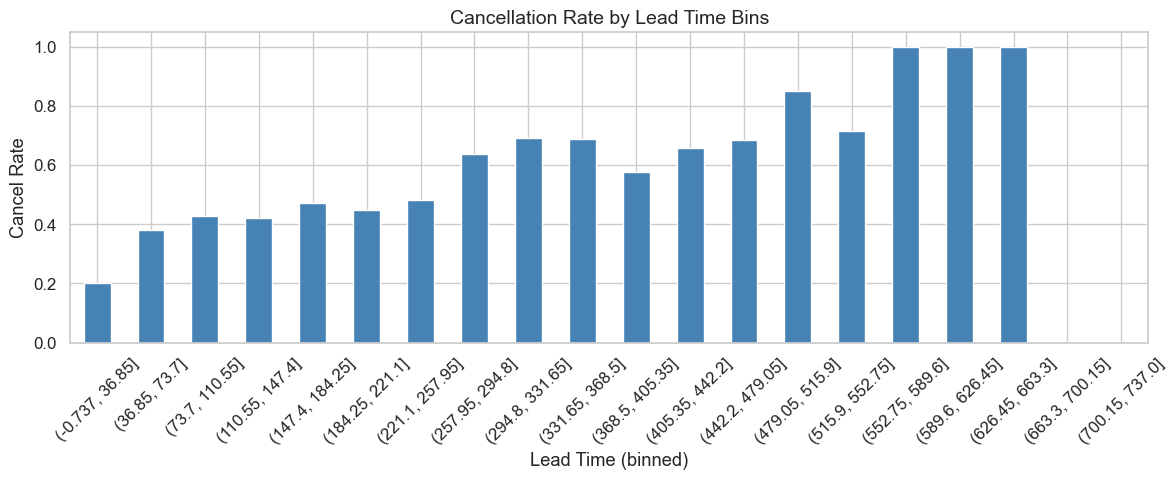

In [10]:
# Lead time vs cancellation
fig, ax = plt.subplots(figsize=(12, 5))
df.groupby(pd.cut(df['lead_time'], bins=20))['is_canceled'].mean().plot(
    kind='bar', color='steelblue', edgecolor='white', ax=ax
)
ax.set_title('Cancellation Rate by Lead Time Bins', fontsize=14)
ax.set_ylabel('Cancel Rate')
ax.set_xlabel('Lead Time (binned)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cancellation_by_lead_time.png', dpi=150)
plt.show()

## 7. Correlation Heatmap

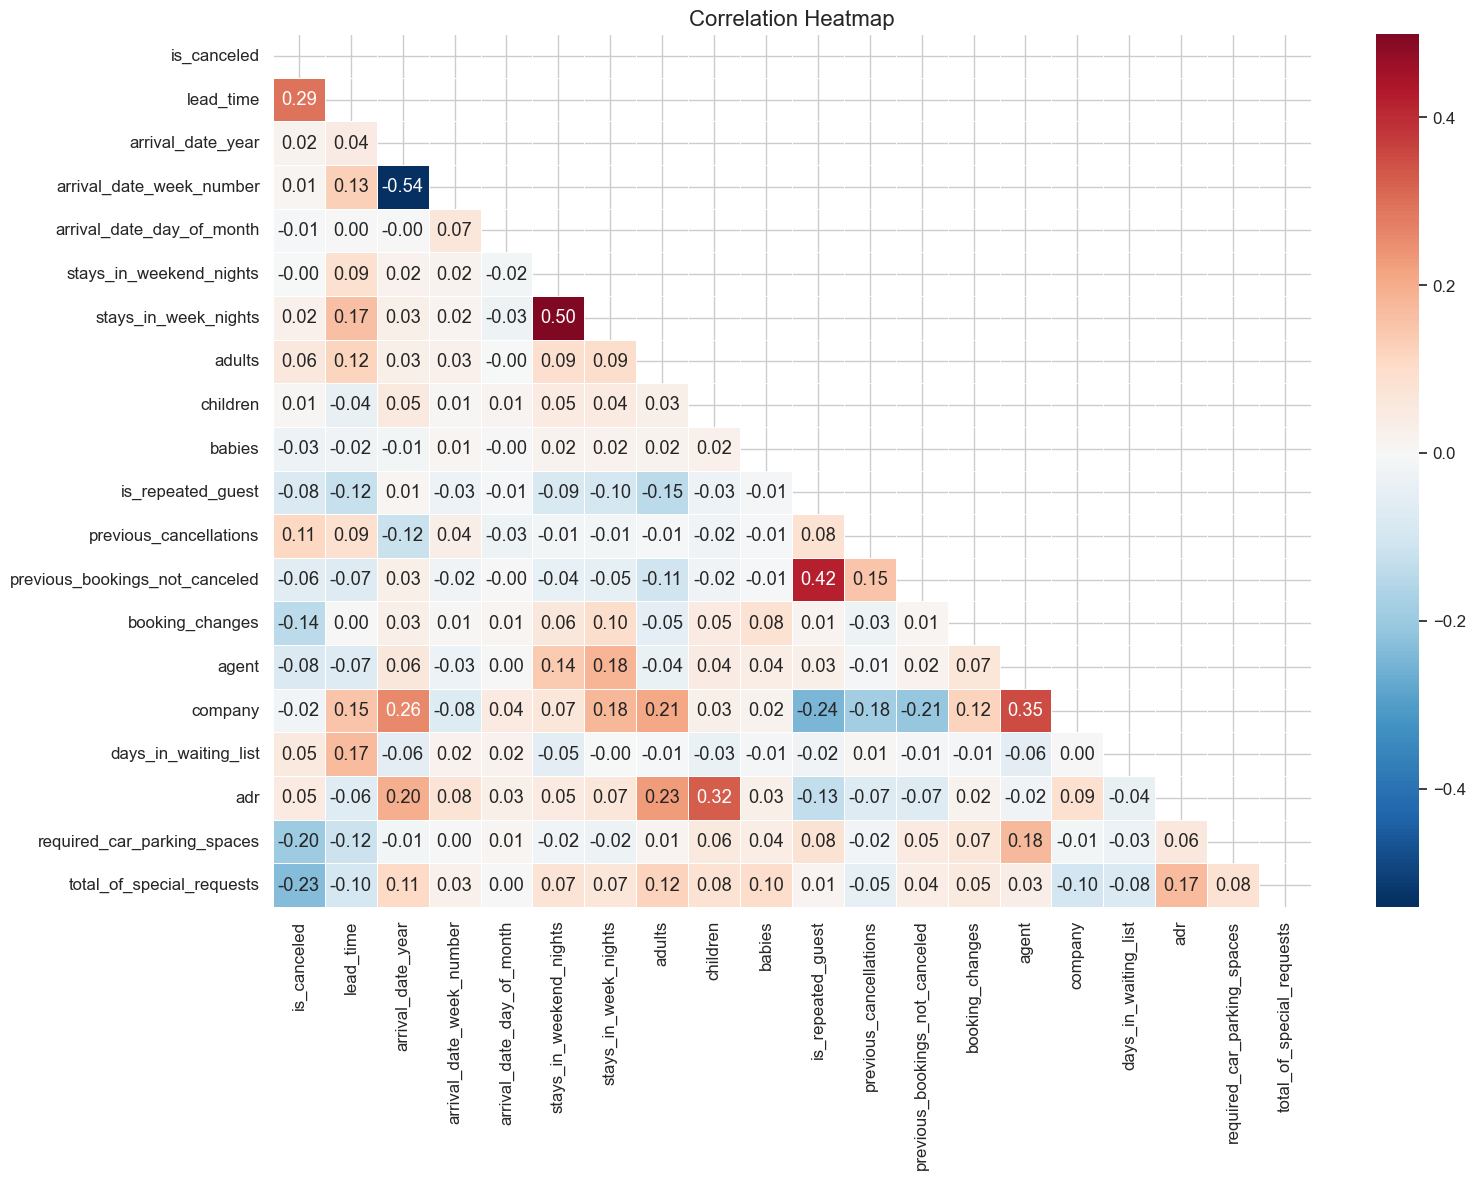

In [11]:
corr = df.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()

## 8. Outlier Detection — Boxplots

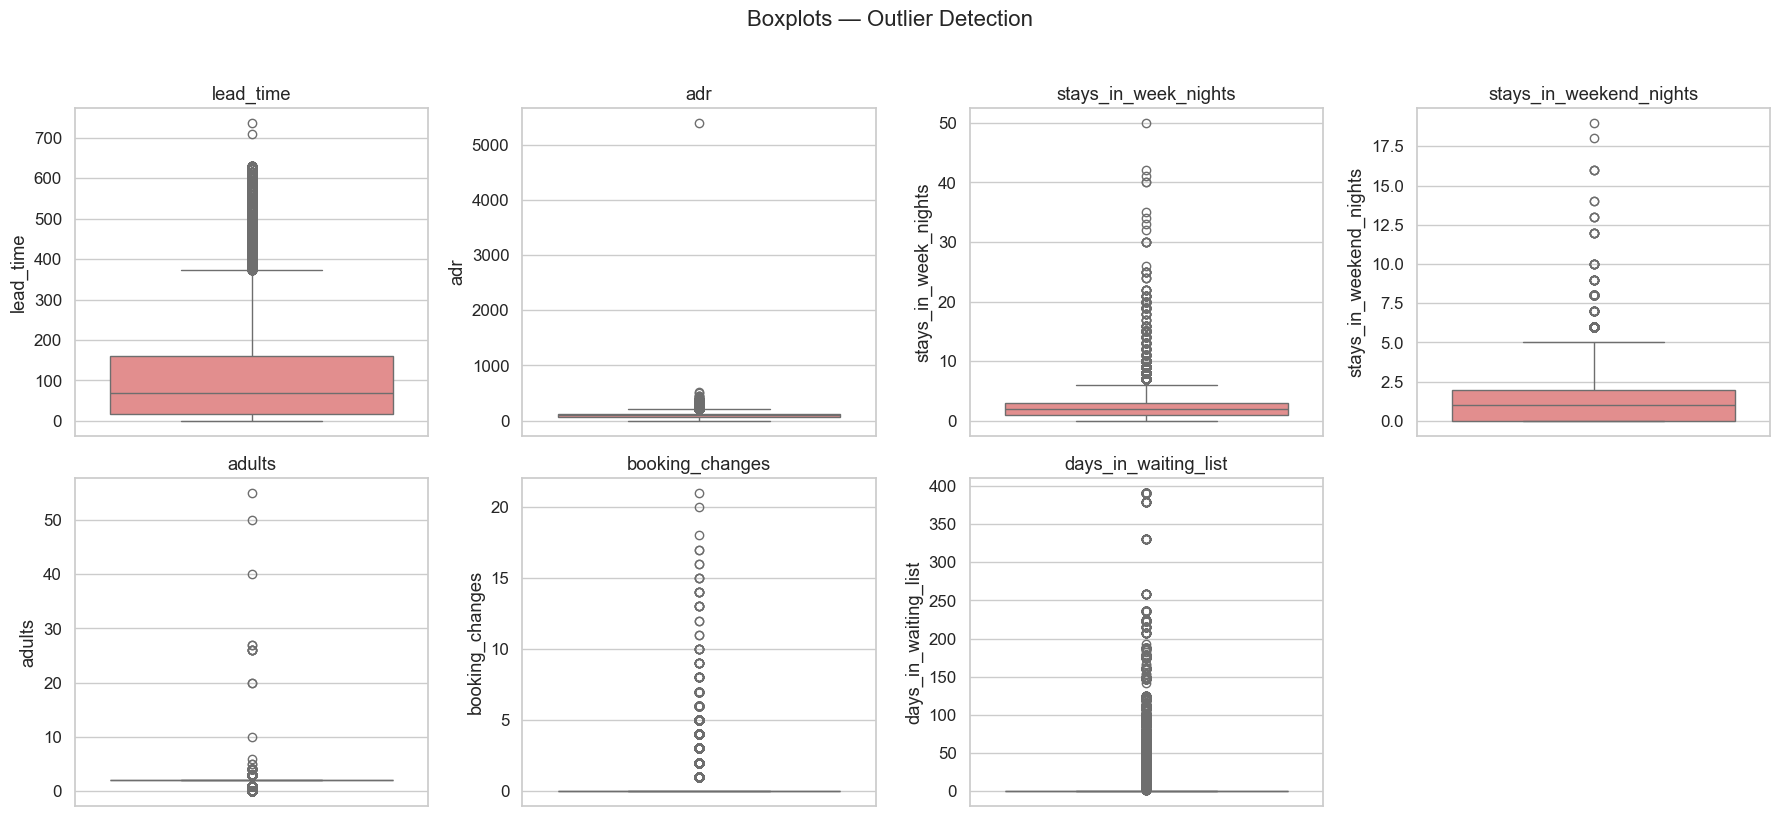

In [12]:
outlier_cols = ['lead_time', 'adr', 'stays_in_week_nights', 'stays_in_weekend_nights',
                'adults', 'booking_changes', 'days_in_waiting_list']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col)

axes[-1].set_visible(False)
plt.suptitle('Boxplots — Outlier Detection', y=1.02, fontsize=16)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'outlier_boxplots.png', dpi=150)
plt.show()

## 9. Country Analysis — Top 15

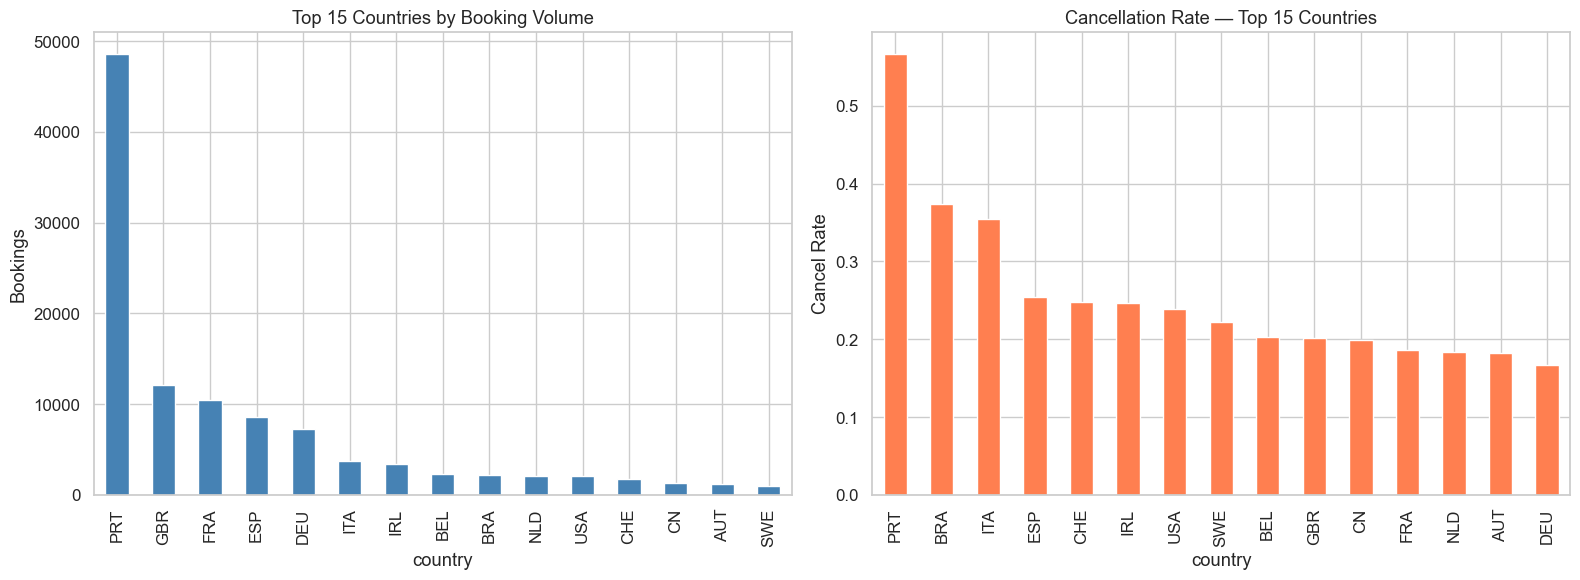

In [13]:
top_countries = df['country'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Volume
top_countries.plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Countries by Booking Volume')
axes[0].set_ylabel('Bookings')

# Cancel rate
cancel_by_country = df[df['country'].isin(top_countries.index)].groupby('country')['is_canceled'].mean()
cancel_by_country.sort_values(ascending=False).plot.bar(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Cancellation Rate — Top 15 Countries')
axes[1].set_ylabel('Cancel Rate')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'country_analysis.png', dpi=150)
plt.show()

## 10. Key Findings Summary

| Finding | Detail |
|---|---|
| Target balance | 37% canceled, 63% not — moderate imbalance |
| High nulls | `company` (94%), `agent` (14%), `country` (0.4%) |
| Data leakage | `reservation_status` perfectly predicts target → must drop |
| Key predictors | `deposit_type`, `lead_time`, `market_segment`, `customer_type` |
| Outliers | `adr` has extreme values (max 5400), negative ADR rows exist |
| City vs Resort | City Hotel has higher cancellation rate (~42%) vs Resort (~28%) |